In [1]:
DATA_PATH = r"../../data/diabetes/diabetes.csv"

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import kendalltau
import copy

import shap

import time

c:\Users\uiv09218\AppData\Local\miniforge3\envs\xai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

In [3]:
df = pd.read_csv(DATA_PATH, header=0)

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
df = df.sample(frac=1).reset_index(drop=True)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,121,78,39,74,39.0,0.261,28,0
1,10,115,0,0,0,35.3,0.134,29,0
2,3,102,74,0,0,29.5,0.121,32,0
3,1,106,76,0,0,37.5,0.197,26,0
4,2,146,70,38,360,28.0,0.337,29,1
...,...,...,...,...,...,...,...,...,...
763,9,120,72,22,56,20.8,0.733,48,0
764,1,115,70,30,96,34.6,0.529,32,1
765,1,103,30,38,83,43.3,0.183,33,0
766,7,147,76,0,0,39.4,0.257,43,1


In [8]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,7,97,76,32,91,40.9,0.871,32
618,3,150,76,0,0,21.0,0.207,37
346,1,118,58,36,94,33.3,0.261,23
294,8,196,76,29,280,37.5,0.605,57
231,0,91,80,0,0,32.4,0.601,27
...,...,...,...,...,...,...,...,...
71,1,128,48,45,194,40.5,0.613,24
106,2,105,58,40,94,34.9,0.225,25
270,2,94,68,18,76,26.0,0.561,21
435,1,89,66,23,94,28.1,0.167,21


---

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=3368494378)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
rf.score(X_test, y_test)

0.8051948051948052

---

X_stds

mutations = []

for _ in range(1000):
    mutations.append(np.random.normal(0, X_stds, size=X_train.values.shape).std(axis=0))

np_mutations = np.array(mutations).mean(axis=0)

np_mutations

In [12]:
def produce_shap_explanations(
    explainer: shap.Explainer,
    dataset: np.ndarray
) -> np.ndarray:
    """
    Produces an array of SHAP explanations for each instance of the given dataset using
    the provided SHAP explainer. The explanations are determined w.r.t. the class 1.

    Parameters
    ----------
    explainer : shap.Explainer
        A SHAP explainer object that can compute SHAP values for instances.

    dataset : np.ndarray
        A numpy array of shape (n_samples, n_features) containing the instances for 
        which local explanations are to be generated.

    Returns
    -------
    np.ndarray
        A 2D numpy array of shape (n_samples, n_features) where each row corresponds to
        the SHAP values for a single instance in the dataset.
    """
    assert isinstance(explainer, shap.Explainer)
    assert isinstance(dataset, np.ndarray)
    assert dataset.ndim == 2

    explanations = explainer(dataset).values[:, :, 1]

    return explanations

In [13]:
def mutate_individual(
    individual: np.ndarray,
    mut_pb: float = 1.0,
    X_min: np.ndarray = None,
    X_max: np.ndarray = None,
    X_stds: np.ndarray = None,
    X_cat: list = None
) -> np.ndarray:
    """
    Mutates a given individual data instance by applying N(0, X_stds[i]) gaussian white noise
    mutations to each continuous feature and another categorical value to each categorical feature
    with a given mutation probability.
    The mutated individual is clipped to the provided feature bounds.

    Parameters
    ----------
    individual (np.ndarray):
        A 1D numpy array representing the individual data instance to be mutated.

    mut_pb (float):
        A float value between 0 and 1 representing the mutation probability for each feature
        in the individual.

    X_min (np.ndarray):
        A 1D numpy array representing the minimum bounds for each feature.

    X_max (np.ndarray):
        A 1D numpy array representing the maximum bounds for each feature.

    X_stds (np.ndarray):
        A 1D numpy array representing the standard deviations for each feature to be used
        for generating the gaussian mutations.

    X_cat (list):
        A list of nd.arrays representing the possible categories for a categorical feature 
        or None if the feature is continuous. The length of the list should be equal to the
        number of features in the individual.

    Returns
    -------
    np.ndarray:
        A new 2D numpy array of the same shape as the input population, containing the mutated
        and clipped data instances.
    """
    assert isinstance(individual, np.ndarray)
    assert 0 <= mut_pb <= 1
    assert isinstance(X_min, np.ndarray)
    assert isinstance(X_max, np.ndarray)
    assert X_min.ndim == 1
    assert X_max.ndim == 1
    assert X_min.shape == X_max.shape
    assert X_min.shape[0] == individual.shape[1]
    assert isinstance(X_stds, np.ndarray)
    assert X_stds.ndim == 1
    assert X_stds.shape[0] == individual.shape[1]
    assert isinstance(X_cat, list)
    assert len(X_cat) == individual.shape[1]
    assert all(isinstance(cat, np.ndarray) or cat is None for cat in X_cat)

    mutated_individual = individual.copy()

    # create gaussian mutations with respective stds
    for feature in range(mutated_individual.shape[1]):
        # categorical feature mutation
        if X_cat[feature] is not None:
            # create a mutation mask
            mutation_mask = np.random.rand(mutated_individual.shape[0]) < mut_pb

            # categorical feature mutation
            mutation_categories = np.random.choice(
                X_cat[feature],
                size=mutated_individual.shape[0]
            )

            # apply mutations according to the mask
            mutated_individual[mutation_mask, feature] = mutation_categories[mutation_mask]
        # continuous feature mutation
        else:
            # create mutation mask
            mutation_mask = np.random.rand(mutated_individual.shape[0]) < mut_pb
            
            # continuous feature mutation
            # mutations = np.random.normal(0, X_stds[feature], size=mutated_individual.shape[0])
            mutations = np.random.normal(0, 1, size=mutated_individual.shape[0])
            
            # apply mutations according to the mask
            mutated_individual[mutation_mask, feature] += mutations[mutation_mask]

    # clip the mutated data to the feature bounds
    clipped_mutated_individual = np.clip(
        mutated_individual,
        X_min,
        X_max
    )

    return clipped_mutated_individual


In [14]:
def init_population(
    reference_data: pd.DataFrame = None,
    cat_mask: list = None,
    population_size: int = 50
) -> list[np.ndarray]:
    """
    Initilizes a population of n individuals by mutating copies of the provided reference data.

    Parameters
    ----------
    reference_data (pd.DataFrame):
        A pandas DataFrame of shape (n_samples, n_features) representing the reference data
        for the individuals to be mutated for the population initialization.

    cat_mask (list):
        A list of booleans indicating whether a feature is categorical (True) or continuous (False).

    n_population (int):
        The number of individuals to initialize the population with.

    Returns
    -------
    list:
        A population of mutated individuals, each represented as a 2D numpy array of shape
        (n_samples, n_features).
    """
    assert isinstance(reference_data, pd.DataFrame)
    assert isinstance(cat_mask, list)
    assert len(cat_mask) == reference_data.shape[1]
    assert all(isinstance(is_cat, bool) for is_cat in cat_mask)
    assert isinstance(population_size, int)
    assert population_size > 0

    population = []

    for _ in range(population_size):
        individual_p = reference_data.copy(deep=True)
        individual_p = mutate_individual(
            individual = individual_p.values,
            mut_pb = 1.0,
            X_min = reference_data.min().values,
            X_max = reference_data.max().values,
            X_stds = reference_data.std().values,
            X_cat = [
                np.unique(reference_data.iloc[:, feature]) if (
                    cat_mask[feature]
                ) else (
                    None
                ) for feature in range(reference_data.shape[1])
            ]
        )

        population.append(individual_p)

    return population

In [15]:
def manhattan_distance(
    vec1: np.ndarray,
    vec2: np.ndarray
) -> float:
    """
    Computes the Manhattan distance between two vectors.

    Parameters
    ----------
    vec1 (np.ndarray):
        A 1D numpy array representing the first vector of explanation importance values.

    vec2 (np.ndarray):
        A 1D numpy array representing the second vector of explanation importance values.

    Returns
    -------
    float:
        The computed Manhattan distance between the two vectors.
    """
    assert isinstance(vec1, np.ndarray)
    assert isinstance(vec2, np.ndarray)
    assert vec1.shape == vec2.shape

    return np.sum(np.abs(vec1 - vec2), axis=-1)

In [16]:
def kendall_tau_distance(
    vec1: np.ndarray, 
    vec2: np.ndarray
) -> float:
    """
    Computes the ranking indices of the given vectors to sort them ascensingly and
    then calculates the Kendall Tau distance between the two rankings using the
    scipy.stats.kendalltau() function.
    Since the function returns a similarity score in the range [-1, 1], it is converted
    to a distance metric in the range [0, 2], i.e. [similar, unsimilar], by computing 
    1 - tau.

    Parameters
    ----------
    vec1 (np.ndarray):
        A 1D numpy array representing the first vector of explanation importance values.

    vec2 (np.ndarray):
        A 1D numpy array representing the second vector of explanation importance values.

    Returns
    -------
    float:
        The computed Kendall Tau distance between the two vectors.
    """
    assert isinstance(vec1, np.ndarray)
    assert isinstance(vec2, np.ndarray)
    assert vec1.shape == vec2.shape

    # produce rankings
    vec1_ranking = np.argsort(vec1, axis=-1)
    vec2_ranking = np.argsort(vec2, axis=-1)

    # compute kendall tau distance for each instance
    taus = np.array([
        kendalltau(vec1_ranking[i], vec2_ranking[i])[0] 
        for i in range(vec1.shape[0])
    ])

    return 1 - taus

In [17]:
def manipulation_loss(
    explanation_importance_values = (None, None),
    distance_fn = None,
    order_ranking_fn = None,
    weights = (0.5, 0.5)
) -> float:
    """
    Produces a loss value based on a weighted combination of a distance function and an order ranking
    function. The functions are applied to the explanation importance values from an explainability 
    method evaluating a data instance before and after a manipulation.

    Parameters
    ----------
    explanation_importance_values (tuple):
        A tuple containing two elements:
        - The importance values before the manipulation attack for every data feature.
        - The importance values after the manipulation attack for every data feature.

    distance_fn (callable):
        A function that computes the distance between two vectors of explanation importance values,
        e.g., L1 or L2 distance.

    order_ranking_fn (callable):
        A function that computes a ranking-based metric, e.g. Kendall Tau distance.

    weights (tuple):
        A tuple containing two weights (w1, w2) that determine the contribution of the distance
        function and the order ranking function to the final loss value respectively.

    Returns
    -------
    float:
        The computed manipulation loss value.
    """
    assert isinstance(explanation_importance_values, tuple)
    assert len(explanation_importance_values) == 2
    assert explanation_importance_values[0] is not None
    assert explanation_importance_values[1] is not None
    assert distance_fn is not None
    assert order_ranking_fn is not None
    assert len(weights) == 2
    assert all(isinstance(w, (int, float)) and 0 <= w for w in weights)

    return weights[0] * distance_fn(explanation_importance_values[0], explanation_importance_values[1]) + \
           weights[1] * order_ranking_fn(explanation_importance_values[0], explanation_importance_values[1])


In [18]:
def explanation_loss(
    mutation_explanations: np.ndarray,
    reference_explanations: np.ndarray,
) -> np.ndarray:
    """
    Computes the loss values for a mutated individual based on the manipulation loss
    between the explanation importance values before and after the mutation.
    The used distance function is the Manhattan distance and the order ranking function
    is the Kendall Tau distance. Both functions contribute equally to the final loss value.

    Parameters
    ----------
    mutation_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the explanation
        importance values for the mutated individual.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the explanation
        importance values for the reference individual.

    Returns
    -------
    np.ndarray:
        A 1D numpy array of shape (n_samples,) containing the computed loss values.
    """
    loss = manipulation_loss(
        explanation_importance_values = (
            reference_explanations,
            mutation_explanations
        ),
        distance_fn = manhattan_distance,
        order_ranking_fn = kendall_tau_distance,
        weights = (0.5, 0.5)
    )

    return loss

In [19]:
def individual_fitness(
    individual: np.ndarray,
    explainer: shap.Explainer,
    reference_explanations: np.ndarray
) -> tuple[float, float]:
    """
    Calculates the performance measures for a given individual dataset by producing
    local SHAP explanations and comparing them to reference explanations.
    The individual's instance explanation losses are averaged to produce a single loss value.
    And the fitness score is computed as 1/(mean(loss) + 1) to produce a fitness measure 
    between 0 and 1.

    Parameters
    ----------
    individual (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) representing the individual
        data instances to be evaluated.

    explainer (shap.Explainer):
        A SHAP explainer object that can compute SHAP values for instances.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the reference
        explanation importance values for comparison.

    Returns
    -------
    tuple:
        A tuple containing:
        - The manipulation loss value (float) averaged over all individuals.
        - The fitness score (float) computed as 1/(mean(loss) + 1) to produce a fitness 
          measure between 0 and 1.
    """
    assert isinstance(individual, np.ndarray)
    assert individual.ndim == 2
    assert isinstance(explainer, shap.Explainer)
    assert isinstance(reference_explanations, np.ndarray)
    assert individual.shape == reference_explanations.shape

    # produce SHAP explanations for every instance
    mutation_explanations = produce_shap_explanations(
        explainer,
        individual
    )

    # calculate the fitness for every instance
    loss = explanation_loss(
        mutation_explanations,
        reference_explanations
    )

    return loss.mean(), 1/(loss.mean() + 1)

In [20]:
def population_fitness(
    population: list[np.ndarray],
    explainer: shap.Explainer,
    reference_explanations: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculates the performance measures for a given population of individuals by producing
    SHAP explanations and comparing them to reference explanations.
    Each individual's instance explanation losses are averaged to produce a single loss value.
    And the fitness scores are computed as 1/(mean(loss) + 1) to produce a fitness measure
    between 0 and 1.

    Parameters
    ----------
    population (list[np.ndarray]):
        A list of individuals, each represented as a 2D numpy array of shape
        (n_samples, n_features).

    explainer (shap.Explainer):
        A SHAP explainer object that can compute SHAP values for instances.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the reference
        explanation importance values for comparison.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]:
        A tuple containing two elements:
        - A 1D numpy array of shape (n_individuals,) containing the manipulation loss values
          averaged for each individual.
        - A 1D numpy array of shape (n_individuals,) containing the fitness scores computed
          as 1/(mean(loss) + 1) to produce a fitness measure between 0 and 1.
    """
    assert isinstance(population, list)
    assert all(isinstance(individual, np.ndarray) for individual in population)
    assert all(individual.ndim == 2 for individual in population)
    assert isinstance(reference_explanations, np.ndarray)
    assert reference_explanations.ndim == 2
    assert all(individual.shape == reference_explanations.shape for individual in population)
    assert isinstance(explainer, shap.Explainer)

    n_pop = len(population)

    start_time = time.time()

    # unify all individuals in a single array without adding a new axis
    pop = np.concatenate(population)

    print(f"Concatenating population took {time.time() - start_time} seconds.")
    section_time = time.time()
    
    # produce SHAP explanations for the entire population
    explanations = produce_shap_explanations(
        explainer,
        pop
    )

    print(f"Producing SHAP explanations for the population took {time.time() - section_time} seconds.")
    section_time = time.time()

    # repeat the reference explanations for all individuals
    # to match the above explanations shape
    reference_explanations_rep = np.tile(
        reference_explanations,
        (n_pop, 1)
    )

    print(f"Repeating reference explanations took {time.time() - section_time} seconds.")
    section_time = time.time()

    # calculate the loss for all individuals
    losses = explanation_loss(
        explanations,
        reference_explanations_rep
    )

    print(f"Calculating explanation losses for the population took {time.time() - section_time} seconds.")
    section_time = time.time()

    # determine quality measures for each individual
    mean_losses = losses.reshape(n_pop, -1).mean(axis=1)
    fitnesses = 1/(mean_losses + 1)

    print(f"Calculating mean losses and fitnesses took {time.time() - section_time} seconds.")

    return mean_losses, fitnesses

class Individual:
    def __init__(
        self,
        data: np.ndarray,
        mutation_prob: float = 1.0,
        explanations: np.ndarray = None,
        fitness: np.ndarray = None
    ):
        self.data = data
        self.mutation_prob = mutation_prob
        self.explanations = explanations
        self.fitness = fitness

test_fitnesses = manipulation_loss(
    explanation_importance_values = (
        reference_explanations[:int(reference_explanations.shape[0]/2), :],
        reference_explanations[int(reference_explanations.shape[0]/2):, :],
    ),
    distance_fn = manhattan_distance,
    order_ranking_fn = kendall_tau_distance,
    weights = (0.5, 0.5)
)

In [21]:
def select_parent_indices(
    fitnesses: np.ndarray,
    elite_prop: float = 0.4,
) -> np.ndarray:
    """
    Selects parent indices for crossover from the elite individuals in the population
    based on their fitness values.
    Dominant individuals (top elite_prop) are used to sample 90% of the parent pairs,
    while the remaining 10% of parent pairs are sampled from both dominant and recessive
    individuals (bottom 1 - elite_prop).

    Parameters
    ----------
    fitnesses (np.ndarray):
        A 1D numpy array of shape (n_population,) containing the fitness values for
        each individual in the population.

    elite_prop (float):
        A float representing the proportion of elite individuals to consider for parent
        selection.

    Returns
    -------
    np.ndarray:
        A 2D numpy array of shape (n_population, 2) containing pairs of selected parent indices
        for crossover.
    """
    assert isinstance(fitnesses, np.ndarray)
    assert fitnesses.ndim == 1
    assert fitnesses.shape[0] >= 2
    assert isinstance(elite_prop, float)
    assert 0 < elite_prop < 1

    individual_ranks = np.argsort(-fitnesses)  # descending order
    k_elite = int(elite_prop * len(fitnesses))
    k_elite = max(2, k_elite)

    elite_population_size = max(1, int(fitnesses.shape[0] * 0.9))  # > 1
    remaining_population_size = fitnesses.shape[0] - elite_population_size  # > 1

    # determine parent pairs only from dominant individuals
    dominant_parent_indices = individual_ranks[:k_elite]
    dominant_parent_pairs = np.random.choice(
        dominant_parent_indices,
        size=2*elite_population_size,
        replace=True
    ).reshape(-1, 2)

    # determine parent pairs from dominant and recessive individuals
    dominant_parents = np.random.choice(
        dominant_parent_indices,
        size=remaining_population_size,
        replace=True
    )
    recessive_parent_indices = individual_ranks[k_elite:]
    recessive_parents = np.random.choice(
        recessive_parent_indices,
        size=remaining_population_size,
        replace=True
    )

    recessive_parent_pairs = np.stack(
        (dominant_parents, recessive_parents),
        axis=-1
    )

    # combine both parent pair sets
    selected_parent_pairs = np.concatenate(
        (dominant_parent_pairs, recessive_parent_pairs),
        axis=0
    )

    return selected_parent_pairs

In [22]:
def crossover_parents(
    dominant_parent: np.ndarray,
    recessive_parent: np.ndarray,
    dominant_fitness: float,
    recessive_fitness: float
) -> np.ndarray:
    """
    Performs crossover between a pair of parent individuals to produce an offspring
    with features inherited from both parents based on their fitness values.

    Parameters
    ----------
    dominant_parent (np.ndarray):
        A 2D numpy array representing the dominant parent individual indicated by the 
        higher fitness value.

    recessive_parent (np.ndarray):
        A 2D numpy array representing the recessive parent individual indicated by the
        lower fitness value.

    dominant_fitness (float):
        A float containing the fitness value for the dominant parent.

    recessive_fitness (float):
        A float containing the fitness value for the recessive parent.

    Returns
    -------
    np.ndarray:
        A 2D numpy array representing the offspring produced from the crossover.
        The offspring has the same shape as the parent individuals.
    """
    assert isinstance(dominant_parent, np.ndarray)
    assert dominant_parent.ndim == 2
    assert isinstance(recessive_parent, np.ndarray)
    assert recessive_parent.ndim == 2
    assert dominant_parent.shape == recessive_parent.shape
    assert isinstance(dominant_fitness, float)
    assert 0 <= dominant_fitness <= 1
    assert isinstance(recessive_fitness, float)
    assert 0 <= recessive_fitness <= 1

    # determine the amount of features to inherit from the dominant parent
    fitness_ratio = dominant_fitness - recessive_fitness  # in [0;1]
    dominant_feature_proportion = max(fitness_ratio, -fitness_ratio + 1)
    dominant_feature_amount = int(dominant_feature_proportion * dominant_parent.shape[1])

    # randomly select the features to inherit from the dominant parent
    dominant_features = np.random.choice(
        dominant_parent.shape[1],
        size=dominant_feature_amount,
        replace=False
    )
    # determine the recessive features as the remaining features
    recessive_features = np.setdiff1d(
        np.arange(dominant_parent.shape[1]),
        dominant_features
    )

    # create offspring by combining the parents' features
    offspring = np.zeros_like(dominant_parent)
    offspring[:, dominant_features] = dominant_parent[:, dominant_features]
    offspring[:, recessive_features] = recessive_parent[:, recessive_features]

    return offspring

In [23]:
def produce_next_generation(
    current_population: list[np.ndarray],
    fitnesses: np.ndarray,
    parent_pair_indices: np.ndarray,
    p_combine: float = 0.6,
    p_mutate: float = 0.4,
    X_min: np.ndarray = None,
    X_max: np.ndarray = None,
    X_stds: np.ndarray = None,
    X_cat: list = None
) -> list[np.ndarray]:
    """
    Produces the next generation of individuals by performing crossover and mutation
    on the current population based on the provided parent pair indices.

    Parameters
    ----------
    current_population (list):
        A list of 2D numpy arrays, each representing an individual dataset in the current
        population.

    fitnesses (np.ndarray):
        A 1D numpy array of shape (n_population,) containing the fitness values for
        each individual in the population.

    parent_pair_indices (np.ndarray):
        A 2D numpy array of shape (n_population, 2) containing pairs of parent indices
        selected for crossover.

    p_combine (float):
        A float representing the probability of combining features from both parents.
        If the random value exceeds this probability, the offspring is created as an exact
        copy of the dominant parent, i.e. the one with the better fitness value.

    p_mutate (float):
        A float representing the mutation probability for each feature in the offspring.

    X_min (np.ndarray):
        A 1D numpy array representing the minimum bounds for each feature.

    X_max (np.ndarray):
        A 1D numpy array representing the maximum bounds for each feature.

    X_stds (np.ndarray):
        A 1D numpy array representing the standard deviations for each feature to be used
        for generating the gaussian mutations.

    X_cat (list):
        A list of nd.arrays representing the possible categories for a categorical feature
        or None if the feature is continuous. The length of the list should be equal to the
        number of features in the individual.

    Returns
    -------
    list:
        A list of 2D numpy arrays, each representing an individual dataset in the next
        generation population. This has the same structure/ shape as the current population.
    """
    assert isinstance(current_population, list)
    assert all(isinstance(individual, np.ndarray) for individual in current_population)
    assert isinstance(fitnesses, np.ndarray)
    assert fitnesses.ndim == 1
    assert fitnesses.shape[0] == len(current_population)
    assert isinstance(parent_pair_indices, np.ndarray)
    assert parent_pair_indices.ndim == 2
    assert parent_pair_indices.shape[0] == len(current_population)
    assert parent_pair_indices.shape[1] == 2
    assert isinstance(p_combine, float)
    assert 0 <= p_combine <= 1
    assert isinstance(p_mutate, float)
    assert 0 <= p_mutate <= 1
    assert isinstance(X_min, np.ndarray)
    assert X_min.ndim == 1
    assert X_min.shape[0] == current_population[0].shape[1]
    assert isinstance(X_max, np.ndarray)
    assert X_max.ndim == 1
    assert X_max.shape[0] == current_population[0].shape[1]
    assert isinstance(X_stds, np.ndarray)
    assert X_stds.ndim == 1
    assert X_stds.shape[0] == current_population[0].shape[1]
    assert isinstance(X_cat, list)
    assert len(X_cat) == current_population[0].shape[1]
    assert all(isinstance(cat, np.ndarray) or cat is None for cat in X_cat)

    next_generation = []

    # produce an offspring for each parent pair
    for parent_indices in parent_pair_indices:
        parents = (
            current_population[parent_indices[0]], 
            current_population[parent_indices[1]]
        )
        fitness_scores = (
            fitnesses[parent_indices[0]], 
            fitnesses[parent_indices[1]]
        )
        # determine dominant and recessive parent
        parent_sorting = np.argsort(fitness_scores)

        # create offspring by combining parents' features
        if np.random.rand() < p_combine:
            offspring = crossover_parents(
                dominant_parent = parents[parent_sorting[1]],
                recessive_parent = parents[parent_sorting[0]],
                dominant_fitness = fitness_scores[parent_sorting[1]],
                recessive_fitness = fitness_scores[parent_sorting[0]]
            )
        else:  # create offspring as an exact copy of the dominant parent
            offspring = parents[parent_sorting[1]].copy()
        
        # mutate the offspring
        offspring = mutate_individual(
            offspring,
            mut_pb = p_mutate,
            X_min = X_min,
            X_max = X_max,
            X_stds = X_stds,
            X_cat = X_cat
        )

        next_generation.append(offspring)
    
    return next_generation

In [24]:
def evolve_population(
    initial_population: list[np.ndarray],
    explainer: shap.Explainer,
    reference_explanations: np.ndarray,
    n_generations: int = 20,
    elite_prop: float = 0.4,
    p_combine: float = 0.6,
    p_mutate: float = 0.4,
    X_min: np.ndarray = None,
    X_max: np.ndarray = None,
    X_stds: np.ndarray = None,
    X_cat: list = None
) -> tuple[list[np.ndarray], list[float], int]:
    """
    Evolves the given initial population over a specified number of generations
    using genetic algorithm operations such as selection, crossover, and mutation.

    Parameters
    ----------
    initial_population (list):
        A list of 2D numpy arrays, each representing an individual dataset in the initial
        population.

    explainer (shap.Explainer):
        A SHAP explainer object that can compute SHAP values for instances built with the
        model and initial data to be evaluated.

    reference_explanations (np.ndarray):
        A 2D numpy array of shape (n_samples, n_features) containing the reference
        explanation importance values for comparison.

    n_generations (int):
        An integer representing the number of generations to evolve the population.

    elite_prop (float):
        A float representing the proportion of elite individuals to consider for parent
        selection as the major foundation to populate the next generation.

    p_combine (float):
        A float representing the probability of combining features from both parents
        during crossover.

    p_mutate (float):
        A float representing the mutation probability for each feature in the offspring.

    X_min (np.ndarray):
        A 1D numpy array representing the minimum bounds for each feature.

    X_max (np.ndarray):
        A 1D numpy array representing the maximum bounds for each feature.

    X_stds (np.ndarray):
        A 1D numpy array representing the standard deviations for each feature to be used
        during mutation.

    X_cat (list):
        A list of nd.arrays representing the possible categories for a categorical feature
        or None if the feature is continuous. The length of the list should be equal to the
        number of features in the individuals.

    Returns
    -------
    list:
        A tuple containing:
        - A list of the best individuals from each generation.
        - A list of the best fitness values from each generation.
        - The index of the generation with the overall best fitness value.
    """
    assert isinstance(initial_population, list)
    assert all(isinstance(individual, np.ndarray) for individual in initial_population)
    assert isinstance(explainer, shap.Explainer)
    assert isinstance(reference_explanations, np.ndarray)
    assert isinstance(n_generations, int)
    assert n_generations > 0
    assert isinstance(elite_prop, float)
    assert 0 < elite_prop < 1
    assert isinstance(p_combine, float)
    assert 0 <= p_combine <= 1
    assert isinstance(p_mutate, float)
    assert 0 <= p_mutate <= 1
    assert isinstance(X_min, np.ndarray)
    assert X_min.ndim == 1
    assert X_min.shape[0] == initial_population[0].shape[1]
    assert isinstance(X_max, np.ndarray)
    assert X_max.ndim == 1
    assert X_max.shape[0] == initial_population[0].shape[1]
    assert isinstance(X_stds, np.ndarray)
    assert X_stds.ndim == 1
    assert X_stds.shape[0] == initial_population[0].shape[1]
    assert isinstance(X_cat, list)
    assert len(X_cat) == initial_population[0].shape[1]

    time_start = time.time()

    best_individuals = []
    best_fitnesses = []
    current_population = copy.deepcopy(initial_population)

    # claculate the fitness for all individuals in the current population
    fitnesses = population_fitness(
        current_population,
        explainer,
        reference_explanations
    )[1]

    print(f"Initial Population - Best Fitness: {np.max(fitnesses):.6f} --- Time: {time.time() - time_start:.2f}s")

    # store the best individual and fitness from the initial population
    best_individual_index = np.argmax(fitnesses)
    best_individuals.append(current_population[best_individual_index])
    best_fitnesses.append(fitnesses[best_individual_index])

    print(f"before evolution --- Time: {time.time() - time_start:.2f}s")

    # evolve over n_generations
    for _ in range(n_generations):
        # select parent pairs for crossover
        parent_pair_indices = select_parent_indices(
            fitnesses,
            elite_prop
        )

        print(f"--- selected parents --- Time: {time.time() - time_start:.2f}s")

        # produce the next generation
        current_population = produce_next_generation(
            current_population,
            fitnesses,
            parent_pair_indices,
            p_combine,
            p_mutate,
            X_min,
            X_max,
            X_stds,
            X_cat
        )

        print(f"--- produced next generation --- Time: {time.time() - time_start:.2f}s")

        # claculate the fitness for all individuals in the current population
        fitnesses = population_fitness(
            current_population,
            explainer,
            reference_explanations
        )[1]

        print(f"--- calculated fitnesses --- Time: {time.time() - time_start:.2f}s")

        # store the best individual and fitness from the initial population
        best_individual_index = np.argmax(fitnesses)
        best_individuals.append(current_population[best_individual_index])
        best_fitnesses.append(fitnesses[best_individual_index])

        print(f"Generation {_+1}/{n_generations} - Best Fitness: {best_fitnesses[-1]:.6f}")
        print(f"--> completed generation --- Time: {time.time() - time_start:.2f}s")

    return best_individuals, best_fitnesses, np.argmax(best_fitnesses)

---

In [25]:
N_POP = 100
N_GEN = 10

P_ELITE = 0.4
P_COMBINE = 0.6
P_MUTATE = 0.4

In [26]:
X_min, X_max, X_stds = X_train.min().values, X_train.max().values, X_train.std().values

In [27]:
explainer = shap.Explainer(rf)

X_instance = X_train.iloc[0, :].values.reshape(1, -1)
shap_values = explainer.shap_values(X_instance)
print("shap values:\n", shap_values, sep="")
print("shap values for Y=1:\n", shap_values[0, :, 1], sep="")

In [28]:
reference_explanations = produce_shap_explanations(
    explainer,
    X_train.values
)
reference_explanations

array([[ 0.09318978, -0.08743526,  0.01556366, ...,  0.12243967,
         0.16124209,  0.13380134],
       [-0.00345979,  0.10537189, -0.03017859, ..., -0.20737633,
        -0.07152403,  0.04890367],
       [-0.04216901, -0.06179216, -0.01594525, ...,  0.02535739,
        -0.05824313, -0.1378156 ],
       ...,
       [-0.02211086, -0.12193715, -0.00708574, ..., -0.10125988,
         0.01431591, -0.07017524],
       [-0.02345754, -0.13109097, -0.00527188, ..., -0.02337147,
        -0.04832375, -0.09429191],
       [-0.01964719, -0.12592051, -0.0124654 , ..., -0.05875831,
         0.06622891, -0.11256624]], shape=(614, 8))

In [29]:
reference_explanations[0]

array([ 0.09318978, -0.08743526,  0.01556366,  0.05101519, -0.02769922,
        0.12243967,  0.16124209,  0.13380134])

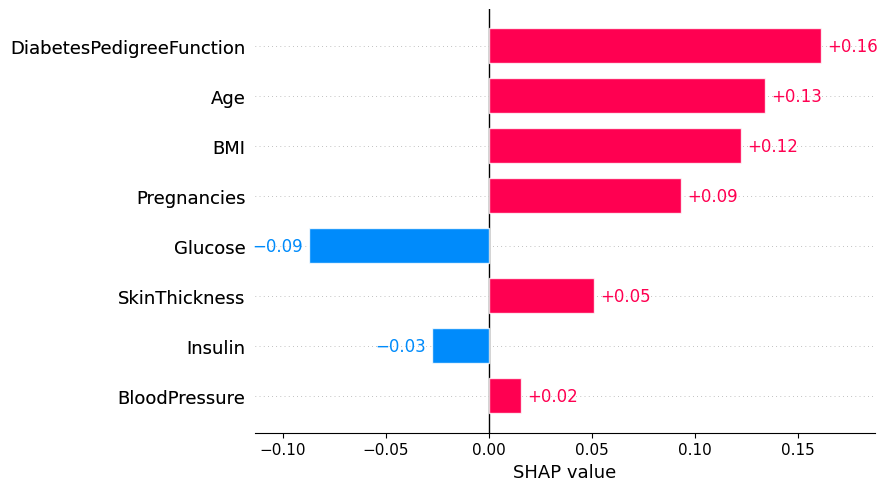

In [30]:
shap.plots.bar(
    shap.Explanation(
        values=reference_explanations[0],
        feature_names=df.columns[:-1],
    ), 
    max_display=20
)

In [31]:
initial_population =  init_population(
    reference_data=X_train,
    cat_mask=[False]*X_train.shape[1],
    population_size=N_POP
)

In [32]:
best_individuals, best_fitnesses, best_generation = evolve_population(
    initial_population = initial_population,
    explainer = explainer,
    reference_explanations = reference_explanations,
    n_generations = N_GEN,
    elite_prop = P_ELITE,
    p_combine = P_COMBINE,
    p_mutate = P_MUTATE,
    X_min = X_min,
    X_max = X_max,
    X_stds = X_stds,
    X_cat = [None]*X_train.shape[1]
)

Concatenating population took 0.00101470947265625 seconds.
Producing SHAP explanations for the population took 80.35262703895569 seconds.
Repeating reference explanations took 0.0 seconds.
Calculating explanation losses for the population took 11.198205947875977 seconds.
Calculating mean losses and fitnesses took 0.0 seconds.
Initial Population - Best Fitness: 0.723567 --- Time: 91.56s
before evolution --- Time: 91.56s
--- selected parents --- Time: 91.56s
--- produced next generation --- Time: 91.58s
Concatenating population took 0.0010013580322265625 seconds.
Producing SHAP explanations for the population took 80.92383670806885 seconds.
Repeating reference explanations took 0.0 seconds.
Calculating explanation losses for the population took 11.617000579833984 seconds.
Calculating mean losses and fitnesses took 0.0 seconds.
--- calculated fitnesses --- Time: 184.13s
Generation 1/10 - Best Fitness: 0.719193
--> completed generation --- Time: 184.13s
--- selected parents --- Time: 184.1

In [33]:
best_fitnesses

[np.float64(0.7235671873680048),
 np.float64(0.7191928615511596),
 np.float64(0.7111235061752622),
 np.float64(0.7072731448829038),
 np.float64(0.7032186173247499),
 np.float64(0.7004467312413468),
 np.float64(0.696596746543981),
 np.float64(0.6953568202754606),
 np.float64(0.6959316079818568),
 np.float64(0.6914972821021116),
 np.float64(0.6872763710061465)]

``Further Approach:`` Inherit feature-wise mutation deviation $\sigma_f$ from parents as e.g. weighted average of parents' deviations, to determine mutation deviations for the offspring.